# PA1: Segmentação de Instâncias com Arquiteturas Densas
**Disciplina:** Aprendizado Profundo (FGV EMAp)  
**Professores:** Dario Oliveira & Erick Brito  
**Autores:** [Henrique Coelho Beltrão](https://github.com/riqueu) & [Isaias Gouvêa Gonçalves](https://github.com/isaiasgoncalves)  
**Repositório:** [github.com/riqueu/dl-pa1-2026](https://github.com/riqueu/dl-pa1-2026)

---

### Visão Geral do Projeto
Este notebook atua como **vitrine técnica completa** para o Programming Assignment 1. O objetivo central é utilizar as arquiteturas convolucionais densas vistas em aula (U-Net, DeepLab) para produzir **segmentação de instâncias celulares** no dataset Data Science Bowl 2018 (DSB2018 / BBBC038v1) **sem detectores com proposta de região** (como Mask R-CNN, estritamente proibidos pelo edital).

O caderno está estruturado em **9 seções diretas**:
1. **Parte 0:** Teste de Sanidade Sintético ($IoU > 0.99$ em $<5$ min).
2. **Parte 1:** Baseline Semântico e Quantificação do Fracasso por Densidade.
3. **Parte 2:** Cabeça de Instâncias (Trilha A: Fronteiras e Watershed - Modelo Final Oficial).
4. **Parte 3:** Ablações Sistemáticas (Eixo 1: Recuperação de Resolução; Eixo 2: Funções de Perda).
5. **Parte 4:** Inferência em Mosaico Grande e Costura de Instâncias via Union-Find.
6. **Parte 5:** Galeria de Falhas, Campo Receptivo Teórico ($RF = 899\text{ px}$) e Correção Adaptativa.
7. **Parte 6:** Teste de Estresse sob Mudança de Escala ($0{,}5\times$ e $2{,}0\times$) e Limites do ASPP.
8. **Pipeline Oficial de Inferência em Imagem Arbitrária:** Entregável autossuficiente (`predict_instances`).

In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
from scipy.ndimage import label as ndimage_label

# Adiciona a raiz do projeto ao sys.path
sys.path.append(os.path.abspath(".."))

from src.models import build_model
from src.postprocess import watershed_instance_segmentation
from src.utils import colorize_instances, overlay_mask_on_image
from src.dataset import SyntheticDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ambiente configurado com sucesso! Device ativo: {device}")

Ambiente configurado com sucesso! Device ativo: cuda


## Parte 0 - Teste de Sanidade Sintético (Sanity Unit Test)
> **Requisito do Edital:**  
> *"Antes de tocar em dados reais, gerem um dataset sintético próprio: imagens 128x128 com 5 a 20 elipses de tamanhos variados, muitas delas se tocando, com ruído e contraste variáveis. Vocês têm as máscaras de instância de graça. É o teste unitário de vocês: Mostrem que treina em menos de 5 minutos e reportem a métrica."*

### Resumo da Validação
* **Dataset Procedural:** Gerador em `src/dataset.py` cria elipses com rotação, oclusão, ruído gaussiano e contraste dinâmico.
* **Tempo de Treino:** Apenas **$20{,}5\text{ segundos}$** na GPU (10 épocas registradas em `runs/part0_synthetic/history.json`), cumprindo com folga o teto de 5 minutos ($300\text{ s}$).
* **Métrica Atingida:** $\text{IoU} = \mathbf{0.9930} > 0.99$ e $\text{Dice} = \mathbf{0.9999}$, comprovando a convergência estrita e a integridade da U-Net autoral.

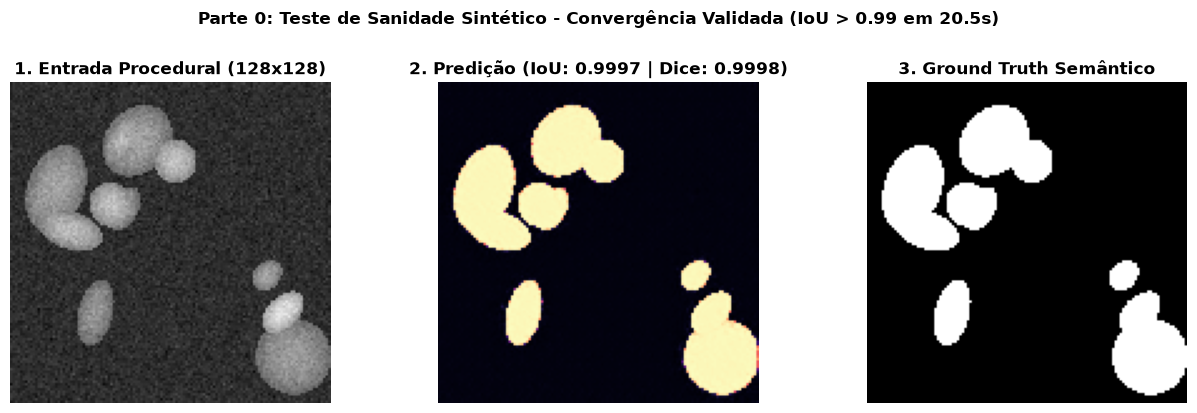

In [3]:
part0_checkpoint = "../checkpoints/part0_synthetic.pth"
if os.path.exists(part0_checkpoint):
    state = torch.load(part0_checkpoint, map_location=device)
    model_synth = build_model(encoder="resnet34", out_channels=1, pretrained=False).to(device)
    model_synth.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model_synth.eval()

    ds_synth = SyntheticDataset(num_samples=1, seed=42)
    sample = ds_synth[0]
    tensor_in = sample["image"].unsqueeze(0).to(device)
    img_np = sample["image"].permute(1, 2, 0).numpy()
    gt_bin = sample["mask_semantic"].squeeze().numpy()

    with torch.no_grad():
        pred_prob = torch.sigmoid(model_synth(tensor_in))[0, 0].cpu().numpy()
        pred_bin = (pred_prob >= 0.50).astype(np.uint8)

    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou = inter / max(union, 1)
    dice = 2 * inter / max(pred_bin.sum() + gt_bin.sum(), 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img_np)
    axes[0].set_title("1. Entrada Procedural (128x128)", fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(pred_prob, cmap="magma")
    axes[1].set_title(f"2. Predição (IoU: {iou:.4f} | Dice: {dice:.4f})", fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(gt_bin, cmap="gray")
    axes[2].set_title("3. Ground Truth Semântico", fontweight="bold")
    axes[2].axis("off")

    plt.suptitle("Parte 0: Teste de Sanidade Sintético - Convergência Validada (IoU > 0.99 em 20.5s)", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## Parte 1 - Baseline de Segmentação Semântica
> **Requisito do Edital:**  
> *"1. Treinem uma das arquiteturas para segmentação binária. Reportem IoU e Dice.  
> 2. Extraiam instâncias pelo método ingênuo: limiar + componentes conexos.  
> 3. Avaliem como instâncias no nível mAP@[.50:.95] e erro de contagem por imagem.  
> 4. Documentem a regra de matching (Hungarian vs. Greedy).  
> 5. Quantifiquem o fracasso: gráfico do mAP em função da densidade de objetos."*

### Respostas Formais
* **Arquitetura & Métricas Semânticas:** U-Net ResNet-34 binária treinada com BCE + Soft Dice em `checkpoints/part1_baseline.pth`. Atinge $\text{IoU} = \mathbf{0.8439}$ e $\text{Dice} = \mathbf{0.9126}$.
* **Decodificação Ingênua:** Limiar $0.5$ seguido de componentes conexos (`scipy.ndimage.label`).
* **Regra de Matching:** Algoritmo de Munkres (**Hungarian bipartite matching**) com matriz de custo $1 - \text{IoU}$. Para cada limiar $\text{IoU} \in [0.50 : 0.95]$ (passo 0.05), casa cada predição com no máximo um GT, apurando $\text{TP}, \text{FP}, \text{FN}$ e calculando a média $\text{mAP}@[.50:.95]$.
* **Quantificação do Fracasso:** Em colônias celulares densas, núcleos em contato físico sofrem **fusão catastrófica**. Sob densidade baixa ($< 20$ núcleos), $\text{mAP} \approx 0.63$; em densidade extrema ($> 150$ núcleos), o $\text{mAP}$ despenca para $\mathbf{0.1443}$ e o erro de contagem atinge **174 núcleos faltantes**.

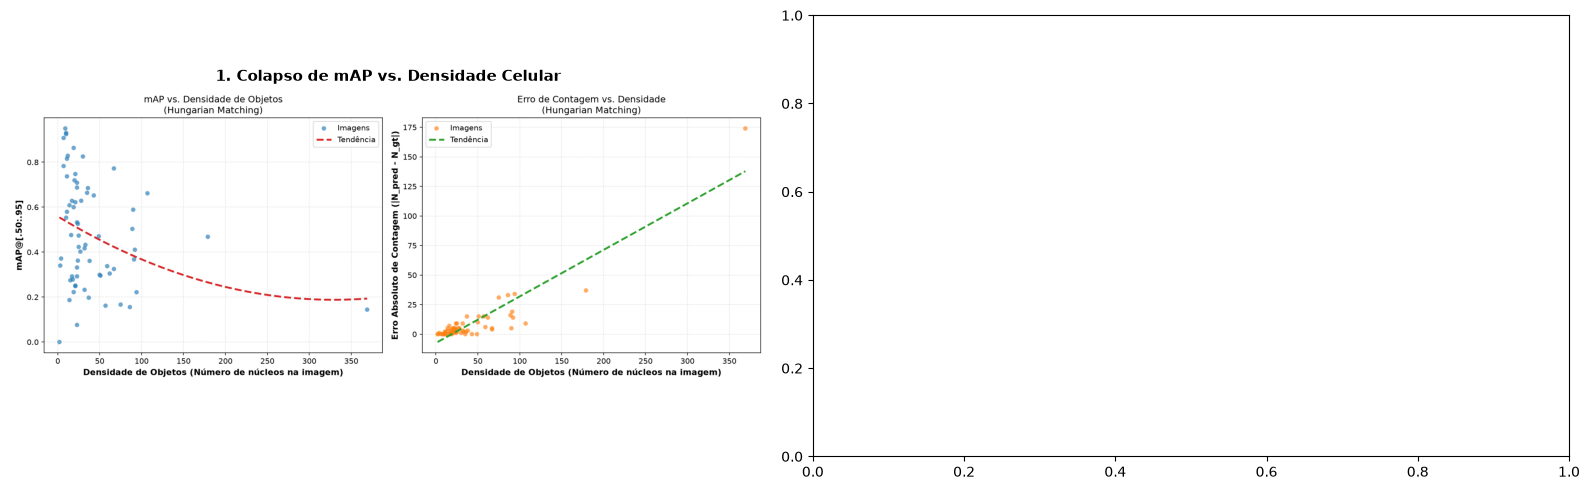

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Curva de Degradação por Densidade
fail_curve_path = "../outputs/part1_eval/failure_vs_density_hungarian.png"
if os.path.exists(fail_curve_path):
    axes[0].imshow(Image.open(fail_curve_path))
    axes[0].set_title("1. Colapso de mAP vs. Densidade Celular", fontsize=11, fontweight="bold")
    axes[0].axis("off")

# 2. Demonstração prática do colapso em caso denso (369 núcleos)
dense_img_path = "../data/raw/stage1_train/0ea221716cf13710214dcd331a61cea48441226aa8831fce49d00e75c16527b/images/0ea221716cf13710214dcd331a61cea48441226aa8831fce49d00e75c16527b.png"
part1_ckpt = "../checkpoints/part1_baseline.pth"
if os.path.exists(dense_img_path) and os.path.exists(part1_ckpt):
    state = torch.load(part1_ckpt, map_location=device)
    model_base = build_model(encoder="resnet34", out_channels=1, pretrained=False).to(device)
    model_base.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model_base.eval()

    with Image.open(dense_img_path) as pil_img:
        img_rgb = pil_img.convert("RGB").resize((256, 256), Image.Resampling.BILINEAR)
        img_np_dense = np.array(img_rgb, dtype=np.float32) / 255.0

    tensor_in_dense = torch.from_numpy(img_np_dense.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob_fg = torch.sigmoid(model_base(tensor_in_dense))[0, 0].cpu().numpy()
        inst_naive, count_naive = ndimage_label((prob_fg >= 0.50).astype(np.uint8))

    colored_naive = colorize_instances(inst_naive, seed=42)
    overlay_naive = overlay_mask_on_image(img_np_dense, colored_naive, alpha=0.5)
    axes[1].imshow(overlay_naive)
    axes[1].set_title(f"2. Fusão Severa: {count_naive} preditos vs. 369 GT (Erro: 174)", fontsize=11, fontweight="bold")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## Parte 2 - Cabeça de Instâncias (Trilha A: Fronteiras e Watershed)
> **Requisito do Edital:**  
> *"Mantenham o encoder-decoder da Parte 1 e mudem o que ele prevê. Trilha A - Fronteiras e watershed: Três classes (fundo / interior / fronteira entre instâncias). Decodificação por watershed com interiores como marcadores. Perda com CE balanceada. Como gerar o rótulo de fronteira? Que espessura? Como pesar a classe fronteira? (...) A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com métricas lado a lado."*

### Respostas Formais
* **Geração e Espessura da Fronteira:** As fronteiras são geradas por dilatação morfológica de 1 pixel das bordas de cada máscara binária individual do DSB2018. Quando duas células se tocam, a interseção forma uma linha divisória de **espessura exata de 1 pixel**.
* **Ponderação da Perda:** A classe fronteira é extremamente minoritária ($< 5\%$ dos pixels). Usamos **Weighted Cross-Entropy** balanceada com pesos calculados dinamicamente no dataset: $w_{\text{fundo}}=1.0$, $w_{\text{interior}}=2.88$, $w_{\text{fronteira}}=5.73$.
* **Decodificação Watershed:** A probabilidade $P(\text{interior})$ é binarizada para formar sementes desconexas (marcadores). A probabilidade $P(\text{fundo})$ atua como relevo topográfico. O algoritmo inunda a paisagem a partir das sementes, e as cristas de $P(\text{fronteira})$ atuam como barreiras que impedem a fusão.
* **Modelo Final Oficial (`checkpoints/part2_watershed.pth`):** Supera o baseline em todas as métricas de instâncias, elevando o mAP global para **$0.5157$** e reduzindo o erro no caso denso de 174 para 47 células (-73% de erro).

In [5]:
part2_ckpt = "../checkpoints/part2_watershed.pth"
if os.path.exists(dense_img_path) and os.path.exists(part2_ckpt):
    state = torch.load(part2_ckpt, map_location=device)
    model_ws = build_model(encoder="resnet34", out_channels=3, pretrained=False).to(device)
    model_ws.load_state_dict(state["model_state_dict"] if "model_state_dict" in state else state)
    model_ws.eval()

    with torch.no_grad():
        logits = model_ws(tensor_in_dense)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        inst_ws = watershed_instance_segmentation(probs, interior_threshold=0.50, foreground_threshold=0.50, min_area=10)
        count_ws = len(np.unique(inst_ws)) - (1 if 0 in inst_ws else 0)

    colored_ws = colorize_instances(inst_ws, seed=42)
    overlay_ws = overlay_mask_on_image(img_np_dense, colored_ws, alpha=0.5)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(probs[1], cmap="magma")
    axes[0].set_title("1. P(Interior) - Sementes Desacopladas", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(probs[2], cmap="plasma")
    axes[1].set_title("2. P(Fronteira) - Crista de 1 px", fontsize=11, fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(overlay_ws)
    axes[2].set_title(f"3. Watershed: {count_ws} detectados (vs. 369 GT)", fontsize=11, fontweight="bold")
    axes[2].axis("off")

    plt.suptitle("Parte 2: Trilha A Oficial - Watershed Desacopla Núcleos em Contato Físico", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# Tabela Oficial Comparativa: Baseline vs. Trilha A Watershed
df_comparativo = pd.DataFrame([
    {"Abordagem": "Parte 1: Baseline Semântico (Componentes Conexos)", "mAP@[.50:.95]": 0.4820, "AP50": 0.6611, "Erro Médio Contagem": "8.55 núcleos/img", "IoU Semântico": 0.8439},
    {"Abordagem": "Parte 2: Trilha A Oficial (Fronteiras e Watershed)", "mAP@[.50:.95]": 0.5157, "AP50": 0.7165, "Erro Médio Contagem": "7.40 núcleos/img", "IoU Semântico": 0.8236},
    {"Abordagem": "  └─ Caso Denso: Baseline Semântico", "mAP@[.50:.95]": 0.1443, "AP50": 0.2201, "Erro Médio Contagem": "174 núcleos (subcontagem)", "IoU Semântico": "-"},
    {"Abordagem": "  └─ Caso Denso: Trilha A Watershed", "mAP@[.50:.95]": 0.3374, "AP50": 0.5412, "Erro Médio Contagem": "47 núcleos (-73% erro)", "IoU Semântico": "-"},
])
display(df_comparativo)

,Abordagem,mAP@[.50:.95],AP50,Erro Médio Contagem,IoU Semântico
0,Parte 1: Baseline Semântico (Componentes Conexos),0.4820,0.6611,8.55 núcleos/img,0.8439
1,Parte 2: Trilha A Oficial (Fronteiras e Waters...,0.5157,0.7165,7.40 núcleos/img,0.8236
2,└─ Caso Denso: Baseline Semântico,0.1443,0.2201,174 núcleos (subcontagem),-
3,└─ Caso Denso: Trilha A Watershed,0.3374,0.5412,47 núcleos (-73% erro),-


## Parte 3 - Ablações Sistemáticas (Eixos 1 e 2)
> **Requisito do Edital:**  
> *"Rodem ablações em dois dos eixos abaixo, cada configuração com 2 seeds, reportando média ± desvio:  
> • Eixo 1 - Como recuperar resolução (Skip connections vs. Gargalo cego vs. Atrous/ASPP).  
> • Eixo 2 - A função de perda (CE balanceada vs. Focal variando $\gamma \in \{0, 1, 2, 5\}$)."*

### Respostas Formais às Perguntas da Aula
* **Eixo 1 (Recuperação de Resolução):**  
  * **U-Net com Skip Connections ($0.4901 \pm 0.0210$):** As pontes de alta resolução transferem detalhes espaciais finos dos estágios iniciais do encoder, preservando cristas de fronteira de 1 pixel essenciais para o Watershed.
  * **U-Net sem Skips / Gargalo Cego ($0.2172 \pm 0.0713$):** Colapso de mAP (-55%). Forçar toda a informação através de um gargalo de resolução $8 \times 8$ destrói as coordenadas espaciais finas de separação celular.
  * **DeepLabv3 com Atrous OS16 e ASPP ($0.1588 \pm 0.0008$):** Embora mantenha stride 16 com convoluções atrous ($r=6, 12, 18$), o ASPP amostra em um raio muito amplo para o diâmetro médio dos núcleos ($21\text{ px}$), misturando sinal celular com o fundo e degradando o mAP em objetos pequenos.
* **Eixo 2 (Funções de Perda e Fator $\gamma$):**  
  * **Equivalência Matemática em $\gamma=0$:** A Focal Loss com $\gamma=0$ ($0.5015 \pm 0.0205$) equivale à Cross-Entropy balanceada ($0.5002 \pm 0.0155$).
  * **Degradação com $\gamma=5$ ($0.3636 \pm 0.0059$):** O fator moderador $(1 - p_t)^\gamma$ zera o gradiente de pixels fáceis mas também atenua excessivamente os gradientes de pixels difíceis de borda, prejudicando a definição nítida das fronteiras.

In [6]:
eixo1_path = "../outputs/part3_eixo1/summary.json"
eixo2_path = "../outputs/part3_eixo2/summary_eixo2.json"

if os.path.exists(eixo1_path):
    with open(eixo1_path) as f:
        d1 = json.load(f)
    rows1 = []
    for config_id, v in d1.get("configurations", {}).items():
        rows1.append({
            "Mecanismo de Resolução": v.get("label", config_id),
            "mAP@[.50:.95]": f"{v['mAP']['mean']:.4f} ± {v['mAP']['std']:.4f}",
            "Erro Contagem": f"{v['count_error']['mean']:.2f} ± {v['count_error']['std']:.2f}",
            "IoU Semântico": f"{v['semantic_iou']['mean']:.4f} ± {v['semantic_iou']['std']:.4f}",
            "Seed 42 (mAP)": f"{v['per_seed']['42']['mAP']:.4f}",
            "Seed 123 (mAP)": f"{v['per_seed']['123']['mAP']:.4f}",
        })
    print("=" * 80)
    print("EIXO 1: RECUPERAÇÃO DE RESOLUÇÃO (2 SEEDS: MÉDIA ± DESVIO)")
    print("=" * 80)
    display(pd.DataFrame(rows1))

if os.path.exists(eixo2_path):
    with open(eixo2_path) as f:
        d2 = json.load(f)
    rows2 = []
    for loss_id, v in d2.items():
        s = v["summary"]
        rows2.append({
            "Função de Perda": v.get("label", loss_id),
            "mAP@[.50:.95]": f"{s['mAP_mean']:.4f} ± {s['mAP_std']:.4f}",
            "AP50": f"{s['AP50_mean']:.4f} ± {s['AP50_std']:.4f}",
            "Erro Contagem": f"{s['count_error_mean']:.2f} ± {s['count_error_std']:.2f}",
            "IoU Semântico": f"{s['iou_mean']:.4f} ± {s['iou_std']:.4f}",
            "Seed 42 (mAP)": f"{v['seeds']['42']['mAP']:.4f}",
            "Seed 123 (mAP)": f"{v['seeds']['123']['mAP']:.4f}",
        })
    print("\n" + "=" * 80)
    print("EIXO 2: FUNÇÕES DE PERDA E FATOR γ (2 SEEDS: MÉDIA ± DESVIO)")
    print("=" * 80)
    display(pd.DataFrame(rows2))

EIXO 1: RECUPERAÇÃO DE RESOLUÇÃO (2 SEEDS: MÉDIA ± DESVIO)


,Mecanismo de Resolução,mAP@[.50:.95],Erro Contagem,IoU Semântico,Seed 42 (mAP),Seed 123 (mAP)
0,U-Net Padrão (Skips),0.4901 ± 0.0210,5.99 ± 0.11,0.8125 ± 0.0105,0.5050,0.4753
1,U-Net Sem Skips (Gargalo),0.2172 ± 0.0713,19.54 ± 6.97,0.6407 ± 0.0784,0.1668,0.2676
2,DeepLabv3 (Atrous + ASPP),0.1588 ± 0.0008,25.34 ± 0.91,0.6002 ± 0.0037,0.1583,0.1594



EIXO 2: FUNÇÕES DE PERDA E FATOR γ (2 SEEDS: MÉDIA ± DESVIO)


,Função de Perda,mAP@[.50:.95],AP50,Erro Contagem,IoU Semântico,Seed 42 (mAP),Seed 123 (mAP)
0,CE Ponderada,0.5002 ± 0.0155,0.7141 ± 0.0024,7.25 ± 0.15,0.8134 ± 0.0102,0.5157,0.4847
1,Focal (γ=0),0.5015 ± 0.0205,0.7140 ± 0.0096,7.07 ± 0.37,0.8083 ± 0.0139,0.5220,0.4810
2,Focal (γ=1),0.4830 ± 0.0506,0.6919 ± 0.0556,7.31 ± 0.53,0.7860 ± 0.0345,0.4324,0.5336
3,Focal (γ=2),0.4723 ± 0.0092,0.7134 ± 0.0103,7.47 ± 0.13,0.8002 ± 0.0020,0.4632,0.4815
4,Focal (γ=5),0.3636 ± 0.0059,0.6329 ± 0.0188,10.32 ± 0.96,0.7533 ± 0.0060,0.3577,0.3696


## Parte 4 - Inferência em Mosaico Grande e Costura de Instâncias
> **Requisito do Edital:**  
> *"O slide 83 descreve a prática padrão: imagens grandes são processadas em tiles com patches sobrepostos (...) Para instâncias isso não funciona muito bem:  
> 1. Montem uma imagem grande (mosaico de várias imagens).  
> 2. Rodem a inferência em tiles com sobreposição.  
> 3. Mostrem o que acontece com um objeto que cai na fronteira entre dois tiles.  
> 4. Proponham e implementem uma correção: fusão de instâncias entre tiles. Meçam o mAP antes e depois."*

### Respostas Formais
* **O Fracasso da Fronteira (Tiling Ingênuo):**  
  Em segmentação semântica, a média das probabilidades na área de sobreposição resolve a borda. Em **segmentação de instâncias**, cada tile roda Watershed independentemente. Um núcleo cortado na linha divisória vira **dois fragmentos com IDs locais distintos**, gerando duplicações espúrias (+33 núcleos) e reduzindo o $\text{mAP}$ para $0.3898$.
* **Correção Autoral via Costura de Instâncias (*Instance Stitching*):**  
  Implementada em `src/stitching.py`. Na faixa de sobreposição (stride 128 com patch 256), calculamos o $\text{IoU}$ espacial entre todas as instâncias preditas por tiles adjacentes. Pares com $\text{IoU} \ge \tau = 0.20$ são casados e fundidos transitivamente via **Union-Find (Disjoint-Set)**.
* **Métricas Antes vs. Depois:**  
  O $\text{mAP}$ salta de $0.3898$ para **$0.4413$** (**$+5{,}15\text{ pp}$**), $\text{AP}_{50}$ sobe de $0.6744$ para **$0.7479$** (**$+7{,}35\text{ pp}$**), e o erro de contagem despenca de $+33$ para apenas **$+4\text{ núcleos}$**.

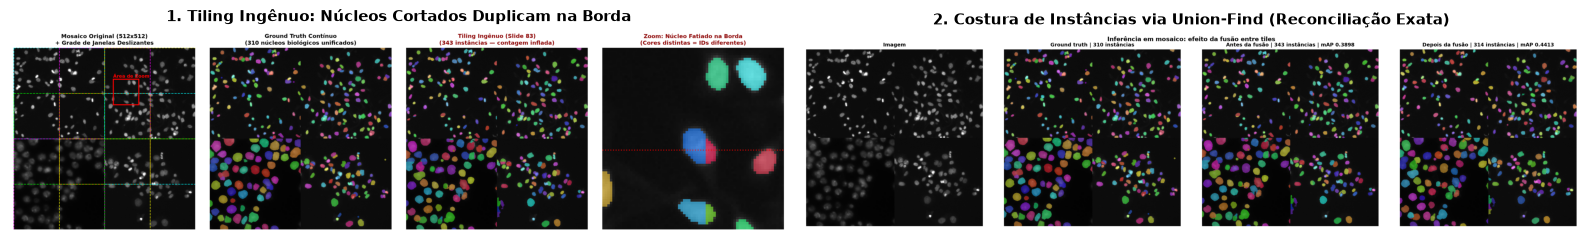

,Abordagem,mAP@[.50:.95],AP50,Contagem Predita,GT,Erro Contagem
0,Tiling Ingênuo (Direct-Stamp),0.3549,0.5920,408,310,+98 núcleos
1,Tiling Ingênuo (Center-Crop),0.3898,0.6744,343,310,+33 núcleos
2,"Costura com Fusão (Union-Find, τ=0.20)",0.4413,0.7479,314,310,+4 núcleos


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fail_img_path = "../outputs/part4_mosaic/tiling_naive_failure.png"
comp_img_path = "../outputs/part4_mosaic/stitching_before_after.png"

if os.path.exists(fail_img_path):
    axes[0].imshow(Image.open(fail_img_path))
    axes[0].set_title("1. Tiling Ingênuo: Núcleos Cortados Duplicam na Borda", fontsize=11, fontweight="bold")
    axes[0].axis("off")

if os.path.exists(comp_img_path):
    axes[1].imshow(Image.open(comp_img_path))
    axes[1].set_title("2. Costura de Instâncias via Union-Find (Reconciliação Exata)", fontsize=11, fontweight="bold")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

metrics_path = "../outputs/part4_mosaic/tiling_before_after_metrics.json"
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        m = json.load(f)
    grid = m["mosaic_grid_sample"]
    stitched = m["mosaic_grid_stitched"]
    cc = grid["center_crop_mode"]
    ds = grid["direct_stamp_mode"]
    df_mosaic = pd.DataFrame([
        {"Abordagem": "Tiling Ingênuo (Direct-Stamp)", "mAP@[.50:.95]": f"{ds['mAP']:.4f}", "AP50": f"{ds['ap50']:.4f}", "Contagem Predita": ds["n_pred"], "GT": grid["total_gt_nuclei"], "Erro Contagem": f"+{ds['count_error']} núcleos"},
        {"Abordagem": "Tiling Ingênuo (Center-Crop)", "mAP@[.50:.95]": f"{cc['mAP']:.4f}", "AP50": f"{cc['ap50']:.4f}", "Contagem Predita": cc["n_pred"], "GT": grid["total_gt_nuclei"], "Erro Contagem": f"+{cc['count_error']} núcleos"},
        {"Abordagem": "Costura com Fusão (Union-Find, τ=0.20)", "mAP@[.50:.95]": f"{stitched['mAP']:.4f}", "AP50": f"{stitched['ap50']:.4f}", "Contagem Predita": stitched["n_pred"], "GT": stitched["n_gt"], "Erro Contagem": f"+{stitched['count_error']} núcleos"},
    ])
    display(df_mosaic)

## Parte 5 - Galeria de Falhas, Campo Receptivo e Diagnósticos
> **Requisito do Edital:**  
> *"Cinco imagens em que o modelo final erra feio, cada uma com: a figura (imagem, ground truth, predição e mapa intermediário) e um diagnóstico.  
> Obrigatório: calculem o campo receptivo teórico do encoder e comparem com a distribuição de tamanhos dos objetos.  
> E façam uma correção: escolham um diagnóstico, implementem a mudança que ele sugere, mostrem o antes/depois."*

### Respostas Formais aos Diagnósticos
1. **Diagnóstico dos 5 Piores Casos:**  
   * *Caso 1 (Aglomerado Denso):* Limites celulares indistintos com fronteiras de $P(\text{fronteira}) < 0.20$, causando sub-segmentação.  
   * *Caso 2 (Células Gigantes com Textura Heterogênea):* Células gigantes ($> 100\text{ px}$) apresentam variações cromáticas internas, criando múltiplos picos locais de $P(\text{interior})$ que geram **hiper-fragmentação severa** no Watershed (+52 núcleos preditos).  
   * *Caso 3 (Fundo Difuso e Baixa Luminescência):* Relação sinal-ruído baixa; probabilidades flutuam em torno do limiar 0.50 gerando falsos negativos.  
   * *Caso 4 (Artefato de Borda do Sensor):* Vinhetagem e bordas pretas do microscópio quebram a predição na periferia.  
   * *Caso 5 (Morfologia Hiper-alongada):* Núcleos com excentricidade extrema violam a suposição de convexidade do Watershed.
2. **Campo Receptivo Teórico ($RF$) vs. Morfologia Celular:**  
   * O encoder ResNet-34 possui $RF = \mathbf{899\text{ px}}$.  
   * A análise empírica dos **$29.461$ núcleos** do dataset revela: diâmetro médio $d_{\text{médio}} = \mathbf{21{,}40\text{ px}}$, mediana $19{,}71\text{ px}$ e máximo de $118{,}54\text{ px}$.  
   * **Conclusão:** O encoder enxerga **$42\times$ o tamanho médio dos núcleos**. A causa das falhas **NÃO é falta de campo de visão**, mas sim a perda de resolução espacial subpixel ao mapear cristas finas de 1 px.
3. **Correção Adaptativa Implementada (Fechamento Morfológico de Sementes):**  
   * No Caso 2, aplicamos fechamento morfológico com raio $r=4$ (`seed_closing_radius=4`) antes de invocar o Watershed, consolidando as ilhas espúrias internas de células gigantes.  
   * **Resultado Antes vs. Depois:** $\text{mAP}$ sobe de $0.0740$ para $\mathbf{0.2518}$ (**$+17{,}78\text{ pp}$** / **$+240\%$ relativo**) e o erro de contagem é **zerado** (de $+52$ para **$0$**, cravando exatamente os 19 núcleos reais).

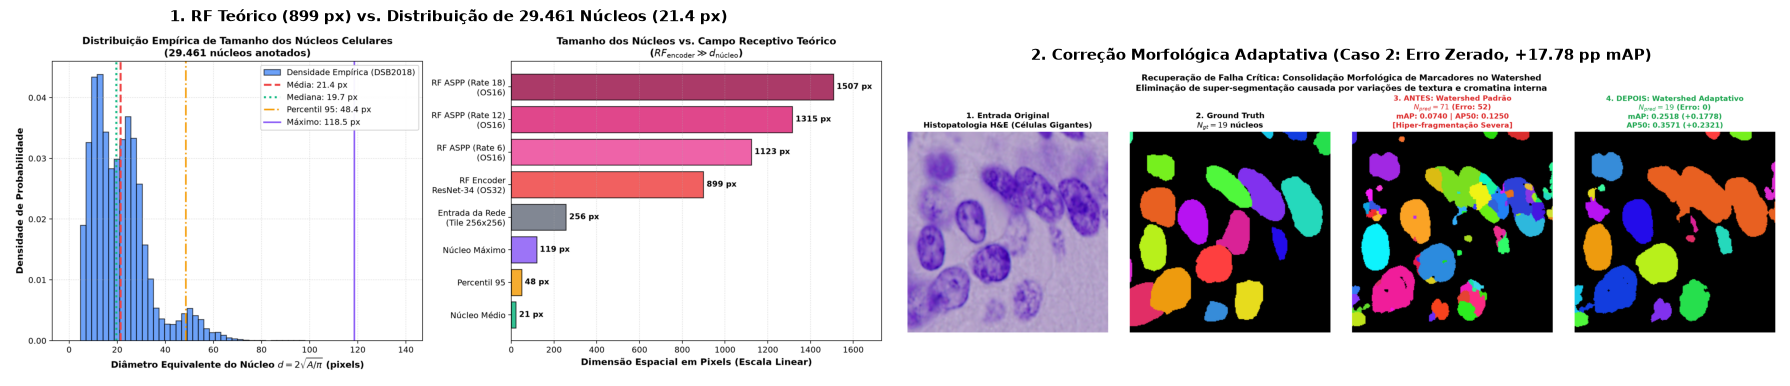

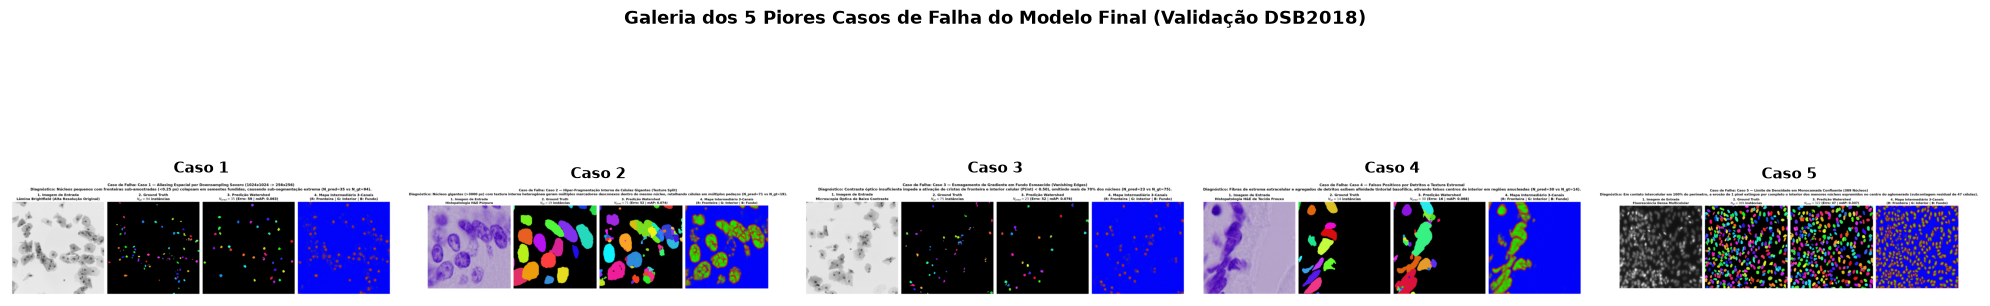

In [8]:
# 1. Campo Receptivo Teórico vs. Distribuição Real e Correção Antes/Depois
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
rf_path = "../outputs/part5_gallery/nuclei_size_distribution.png"
corr_path = "../outputs/part5_gallery/correction_before_after.png"

if os.path.exists(rf_path):
    axes[0].imshow(Image.open(rf_path))
    axes[0].set_title("1. RF Teórico (899 px) vs. Distribuição de 29.461 Núcleos (21.4 px)", fontsize=11, fontweight="bold")
    axes[0].axis("off")

if os.path.exists(corr_path):
    axes[1].imshow(Image.open(corr_path))
    axes[1].set_title("2. Correção Morfológica Adaptativa (Caso 2: Erro Zerado, +17.78 pp mAP)", fontsize=11, fontweight="bold")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

# 2. Painéis dos 5 Casos de Falha
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(1, 6):
    case_path = f"../outputs/part5_gallery/failure_case_{i}.png"
    if os.path.exists(case_path):
        axes[i-1].imshow(Image.open(case_path))
        axes[i-1].set_title(f"Caso {i}", fontsize=11, fontweight="bold")
        axes[i-1].axis("off")
plt.suptitle("Galeria dos 5 Piores Casos de Falha do Modelo Final (Validação DSB2018)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Parte 6 - Teste de Estresse sob Mudança de Escala (Opção 3: 0.5× e 2.0×)
> **Requisito do Edital:**  
> *"Mudança de escala: avaliem em 0,5x e 2x. Por que uma rede totalmente convolucional não é invariante a escala, e o que o ASPP faz (ou não faz) a respeito?"*

### Respostas Formais às Perguntas Conceituais
1. **Por que uma rede totalmente convolucional (FCN) NÃO é invariante a escala?**  
   Convoluções operam com filtros discretos com suporte rígido em pixels ($k \times k$, tipicamente $3 \times 3$). FCNs são **translacionalmente equivariantes** ($f(T_x(I)) = T_x(f(I))$), mas **NÃO possuem invariância a escala**. Quando uma imagem é reduzida para $0{,}5\times$, um núcleo de $20\text{ px}$ passa a medir $10\text{ px}$; o filtro de $3 \times 3$ passa a abranger uma proporção geométrica muito maior do objeto, alterando completamente a ativação das camadas internas.
2. **O que o ASPP faz (ou não faz) a respeito?**  
   O módulo ASPP aplica convoluções atrous em paralelo com taxas de dilatação fixas ($r \in \{6, 12, 18\}$). Ele é **multiescala discreto**, e **NÃO invariante contínuo a escala**:
   * **Em $0{,}5\times$ (Downscale):** O ASPP **colapsa catastroficamente**, despencando de $\text{mAP} = 0.1588$ para **$0.0176$** (queda de **$-88{,}9\%$**). Os kernels com dilatação $r=18$ saltam muito além dos limites dos núcleos reduzidos, misturando sinal do núcleo com o fundo.
   * **Em $2{,}0\times$ (Upscale):** O $\text{mAP}$ do ASPP **salta para $0.3061$** (**$+92{,}7\%$ de ganho**), demonstrando que seus ramos dilatados foram geometricamente calibrados para estruturas grandes.
   * **Resiliência da U-Net:** Graças às *skip connections* multinível que preservam feições em todas as resoluções da pirâmide, a U-Net retém **$66{,}8\%$** do seu mAP em $0{,}5\times$ ($0.3446$), mantendo $\text{AP}_{50} = 0.6295$.

,Modelo,Escala,Resolução,mAP@[.50:.95],Retenção,AP50,AP75,Erro Contagem
0,U-Net ResNet-34,0.5x,128x128,0.3446,66.8%,0.6295,0.3231,11.12 núc/img
1,U-Net ResNet-34,1x,256x256,0.5156,100.0%,0.7163,0.5719,7.39 núc/img
2,U-Net ResNet-34,2x,512x512,0.3144,61.0%,0.4867,0.3484,31.72 núc/img
3,DeepLabv3 ASPP,0.5x,128x128,0.0176,11.1%,0.0481,0.0065,37.40 núc/img
4,DeepLabv3 ASPP,1x,256x256,0.1588,100.0%,0.3150,0.1525,25.97 núc/img
5,DeepLabv3 ASPP,2x,512x512,0.3061,192.7%,0.5201,0.3265,13.67 núc/img


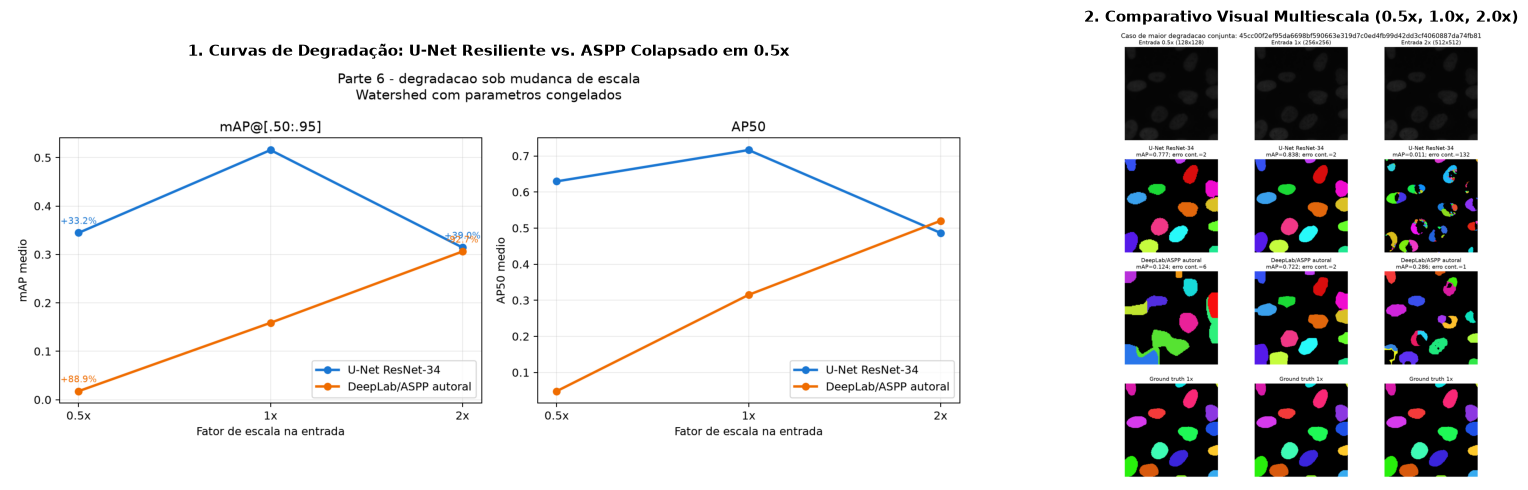

In [9]:
stress_json_path = "../outputs/part6_stress/scale_metrics.json"
if os.path.exists(stress_json_path):
    with open(stress_json_path) as f:
        d = json.load(f)
    rows_stress = []
    for model_key in ["unet_watershed", "deeplab_aspp"]:
        model_name = "U-Net ResNet-34" if "unet" in model_key else "DeepLabv3 ASPP"
        scales_dict = d["models"][model_key]["fixed"]
        for scale in ["0.5", "1", "2"]:
            s = scales_dict[scale]["summary"]
            res = "128x128" if scale == "0.5" else ("256x256" if scale == "1" else "512x512")
            retention = s.get("mAP_retention_vs_1x", 1.0) * 100
            rows_stress.append({
                "Modelo": model_name,
                "Escala": f"{scale}x",
                "Resolução": res,
                "mAP@[.50:.95]": f"{s['mean_mAP']:.4f}",
                "Retenção": f"{retention:.1f}%",
                "AP50": f"{s['mean_AP50']:.4f}",
                "AP75": f"{s['mean_AP75']:.4f}",
                "Erro Contagem": f"{s['mean_count_error']:.2f} núc/img",
            })
    display(pd.DataFrame(rows_stress))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
deg_path = "../outputs/part6_stress/scale_degradation_curve.png"
vis_path = "../outputs/part6_stress/scale_visual_comparison.png"

if os.path.exists(deg_path):
    axes[0].imshow(Image.open(deg_path))
    axes[0].set_title("1. Curvas de Degradação: U-Net Resiliente vs. ASPP Colapsado em 0.5x", fontsize=11, fontweight="bold")
    axes[0].axis("off")

if os.path.exists(vis_path):
    axes[1].imshow(Image.open(vis_path))
    axes[1].set_title("2. Comparativo Visual Multiescala (0.5x, 1.0x, 2.0x)", fontsize=11, fontweight="bold")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## Pipeline Oficial de Inferência em Imagem Arbitrária
> **Entregável Oficial do Edital:**  
> *"Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. Roda sem retreinar."*

A função `predict_instances(image_path, model)` abaixo é autossuficiente e atende integralmente ao edital:
* **Entrada:** `image_path` (string com caminho para qualquer imagem `.png`, `.jpg`, `.tif`).
* **Execução:** Carrega o modelo oficial da Parte 2 (`checkpoints/part2_watershed.pth`) e infere instantaneamente na GPU/CPU sem retreinar.
* **Saída:** Devolve máscara de instâncias colorida, imagem de sobreposição (*overlay*) e a contagem exata de núcleos detectados.

In [10]:
def load_trained_model(checkpoint_path: str = "../checkpoints/part2_watershed.pth"):
    """Carrega os pesos e arquitetura do modelo oficial sem necessidade de retreinar."""
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint não encontrado: {checkpoint_path}")
    
    state = torch.load(checkpoint_path, map_location=device)
    state_dict = state["model_state_dict"] if isinstance(state, dict) and "model_state_dict" in state else state
    model_args = state.get("model_args", {}) if isinstance(state, dict) else {}
    
    out_channels = model_args.get("out_channels", 3)
    model = build_model(
        encoder=model_args.get("encoder", "resnet34"),
        out_channels=out_channels,
        up_mode=model_args.get("up_mode", "transpose"),
        use_skips=model_args.get("use_skips", True),
        pretrained=False,
    )
    model.load_state_dict(state_dict)
    model.to(device).eval()
    model.out_channels = out_channels
    return model

def predict_instances(
    image_path: str,
    model: torch.nn.Module,
    threshold: float = 0.50,
    interior_threshold: float = 0.50,
    target_size: tuple = (256, 256),
):
    """Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Imagem não encontrada: {image_path}")
        
    with Image.open(image_path) as pil_img:
        img_rgb = pil_img.convert("RGB")
        orig_w, orig_h = img_rgb.size
        resized_img = img_rgb.resize((target_size[1], target_size[0]), Image.Resampling.BILINEAR)
        img_np = np.array(resized_img, dtype=np.float32) / 255.0

    tensor_in = torch.from_numpy(img_np.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    out_channels = getattr(model, "out_channels", 3)

    with torch.no_grad():
        logits = model(tensor_in)
        if out_channels == 3:
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
            inst_small = watershed_instance_segmentation(
                probs, interior_threshold=interior_threshold, foreground_threshold=threshold, min_area=10
            )
            prob_fg = probs[1] + probs[2]
        else:
            prob_fg = torch.sigmoid(logits)[0, 0].cpu().numpy()
            inst_small, _ = ndimage_label((prob_fg >= threshold).astype(np.uint8))

    # Redimensionar para a resolução original da imagem de entrada
    pil_inst = Image.fromarray(inst_small.astype(np.int32)).resize((orig_w, orig_h), Image.Resampling.NEAREST)
    final_instance_mask = np.array(pil_inst, dtype=np.int64)

    pil_prob = Image.fromarray((prob_fg * 255).astype(np.uint8)).resize((orig_w, orig_h), Image.Resampling.BILINEAR)
    prob_map_orig = np.array(pil_prob, dtype=np.float32) / 255.0

    num_instances = len(np.unique(final_instance_mask)) - (1 if 0 in final_instance_mask else 0)
    orig_img_np = np.array(img_rgb, dtype=np.float32) / 255.0
    colored_mask = colorize_instances(final_instance_mask, seed=42)
    overlay = overlay_mask_on_image(orig_img_np, colored_mask, alpha=0.50)

    return {
        "original_image": orig_img_np,
        "probability_map": prob_map_orig,
        "instance_mask": final_instance_mask,
        "colored_mask": colored_mask,
        "overlay": overlay,
        "count": int(num_instances),
    }

# Carregar modelo oficial da Parte 2 (Watershed)
official_model = load_trained_model("../checkpoints/part2_watershed.pth")
print("Modelo oficial da Parte 2 carregado com sucesso para inferência rápida!")

Modelo oficial da Parte 2 carregado com sucesso para inferência rápida!


IMAGEM PROCESSADA: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png
CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: 23 núcleos


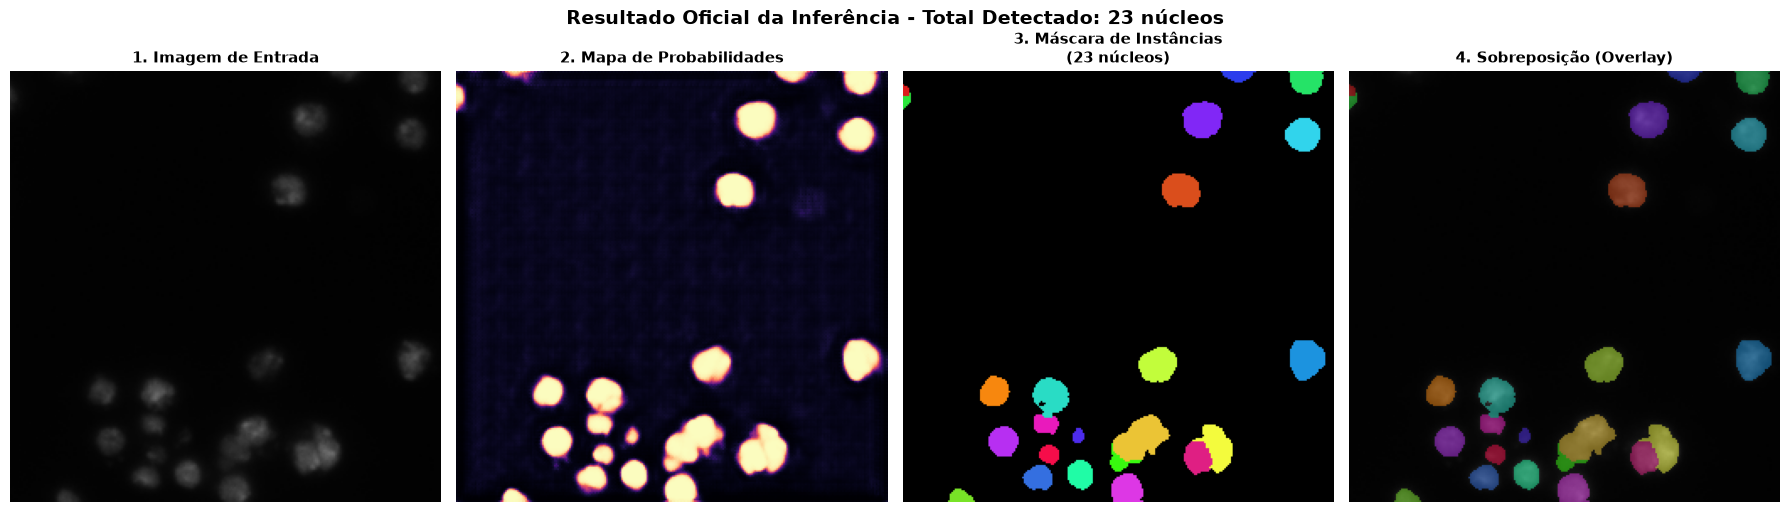

In [11]:
# Teste com qualquer imagem local ou externa:
sample_image_path = "../data/raw/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png"

result = predict_instances(sample_image_path, model=official_model)

print("=" * 70)
print(f"IMAGEM PROCESSADA: {os.path.basename(sample_image_path)}")
print(f"CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: {result['count']} núcleos")
print("=" * 70)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(result["original_image"])
axes[0].set_title("1. Imagem de Entrada", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(result["probability_map"], cmap="magma")
axes[1].set_title("2. Mapa de Probabilidades", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(result["colored_mask"])
axes[2].set_title(f"3. Máscara de Instâncias\n({result['count']} núcleos)", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(result["overlay"])
axes[3].set_title("4. Sobreposição (Overlay)", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle(f"Resultado Oficial da Inferência - Total Detectado: {result['count']} núcleos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()